# 计算背鳍清晰度

In [16]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from blur_detector_torch import BlurDetector
from matplotlib import pyplot as plt

import image_grid

In [3]:
blur_detector = BlurDetector("models/blur_detection_resnet101_final.pth")

已加载模型: models/blur_detection_resnet101_final.pth


In [4]:
root_dir = "/media/filming/2025-白海豚/20240824_JM_01_v2/"

In [24]:
fin_dataset = pd.read_csv(
    "/media/filming/2025-白海豚/20240824_JM_01_v2/FIN_METAINFO.csv", index_col=0)

In [26]:
# test on one fin image
ret = blur_detector.predict("/home/hf/working/中华白海豚/mydata/20240824_JM_01_v2//%s"%fin_dataset.path[1])
print(ret)

{'class': 'clear', 'class_idx': 0, 'confidence': 0.9941030144691467, 'probabilities': {'clear': 0.9941030144691467, 'blur': 0.0058969771489501}}


In [25]:
fin_dataset

,identify,path,crop_conf,x_min,x_max,y_min,y_max,orig_img,orig_img_h,orig_img_w
0,0,FIN/0001_20240824JM01ZRA10001_FIN00.JPG,0.849361,1685,1961,1273,1436,0001_20240824JM01ZRA10001.JPG,2880,4320
1,1,FIN/0002_20240824JM01ZRA10002_FIN00.JPG,0.848547,1661,1976,1302,1481,0002_20240824JM01ZRA10002.JPG,2880,4320
2,2,FIN/0003_20240824JM01ZRA10003_FIN00.JPG,0.856377,1666,1994,1428,1617,0003_20240824JM01ZRA10003.JPG,2880,4320
3,3,FIN/0004_20240824JM01ZRA10004_FIN00.JPG,0.860732,1711,2038,1548,1738,0004_20240824JM01ZRA10004.JPG,2880,4320
4,4,FIN/0005_20240824JM01ZRA10005_FIN00.JPG,0.852788,1801,2128,1545,1735,0005_20240824JM01ZRA10005.JPG,2880,4320
...,...,...,...,...,...,...,...,...,...,...
2573,2573,FIN/2779_20240824JM01ZRA12781_FIN00.JPG,0.641742,1864,2450,1245,1632,2779_20240824JM01ZRA12781.JPG,2880,4320
2574,2574,FIN/2780_20240824JM01ZRA12782_FIN00.JPG,0.856484,1542,2088,1351,1707,2780_20240824JM01ZRA12782.JPG,2880,4320
2575,2575,FIN/2781_20240824JM01ZRA12783_FIN00.JPG,0.856911,1516,2012,1489,1809,2781_20240824JM01ZRA12783.JPG,2880,4320
2576,2576,FIN/2782_20240824JM01ZRA12784_FIN00.JPG,0.818211,1739,2195,1581,1852,2782_20240824JM01ZRA12784.JPG,2880,4320


In [27]:
%%time
clearness_list = []
for i in tqdm(fin_dataset.path):
    ret = blur_detector.predict( root_dir + "/" + i)
    clearness_list.append( ret['probabilities']['clear'] )
fin_dataset["clearness"] = clearness_list
fin_dataset.to_csv("/media/filming/2025-白海豚/20240824_JM_01_v2/FIN_METAINFO.csv")

100%|██████████| 2578/2578 [01:30<00:00, 28.38it/s]

CPU times: user 8min 8s, sys: 2.14 s, total: 8min 11s
Wall time: 1min 30s


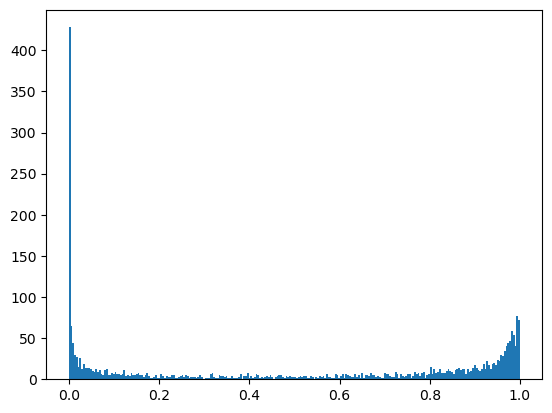

In [30]:
plt.hist(fin_dataset.clearness, bins=256)
plt.show()